In [68]:
import math

import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from skimage.morphology import disk, opening, closing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn import metrics
from pathlib import Path
from tqdm import tqdm
import glob


from toolbox_34759.clustering import plot_elbow_graph
from toolbox_34759.camera_model import PinholeCameraModel, CameraMatrix
from toolbox_34759.coordinates import EuclideanPoint, HomogeneousPoint
from toolbox_34759.visual_odometry import StereoVisualOdometry

In [69]:
DATA_PATH = Path('exams/2024')

# Q11

In [70]:
img = cv2.imread(DATA_PATH / 'images' / 'corners.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

corners = cv2.cornerHarris(gray, blockSize=5, ksize=11, k=0.09)
(corners > 5e5).sum()

np.int64(14146)

# Q19

In [71]:
p = 0.95
w = 0.8
np.log(1-p)/np.log(1-w**2)

np.float64(2.932245500400284)

In [72]:
p = 0.95
w = 0.6
np.log(1-p)/np.log(1-w**2)

np.float64(6.712567439010778)

# Q23

In [73]:
clustering_path = DATA_PATH / 'clustering'
data = np.loadtxt(clustering_path / 'clusters.txt', dtype=np.float32)


Best K: 8


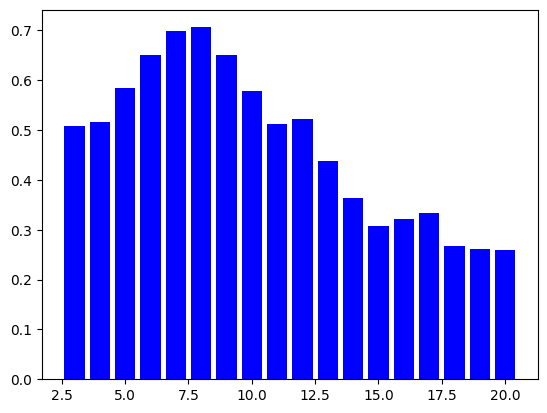

In [74]:
max_k = None
max_score = -float('inf')
for k in range(3,21):
    km = KMeans(n_clusters=k)
    labels = km.fit_predict(data)
    score = silhouette_score(data, labels)
    
    if score > max_score:
        max_score = score
        max_k = k

    plt.bar(k, score, color='blue')

print("Best K:", max_k)

In [75]:
pca = PCA(0.75)
pca.fit(data)

pca.n_components_

np.int64(2)

In [76]:
np.pi/2

1.5707963267948966

# Q24

In [77]:
lr_path = DATA_PATH / 'regression'
X = np.loadtxt(lr_path /'X.txt', dtype=np.float32).reshape(-1,1)
y = np.loadtxt(lr_path /'y.txt', dtype=np.float32).reshape(-1,1)

X_sq = np.pow(X,2)
X_sq.shape
X_aug = np.hstack([X_sq,X])
X_aug.shape

(100, 2)

In [78]:
lr = LinearRegression()
lr.fit(X_aug,y)

lr.coef_, lr.intercept_

(array([[0.22263531, 0.3456045 ]], dtype=float32),
 array([-0.457798], dtype=float32))

# Q27

In [79]:
dt = 0.5
F = np.array([
    [1,0,dt,0,0.5*dt**2, 0],
    [0,1,0,dt,0,0.5*dt**2],
    [0,0,1,0,dt,0],
    [0,0,0,1,0,dt],
    [0,0,0,0,1,0],
    [0,0,0,0,0,1]
])
p0 = np.array([2,3.5]).reshape(-1,1)
v0 = np.array([0.3,1.2]).reshape(-1,1)
b0 = 0.2
w0 = 0

X0 = np.vstack([p0,v0,b0,w0])

X0_5 = F@X0
X0_5


array([[2.175],
       [4.1  ],
       [0.4  ],
       [1.2  ],
       [0.2  ],
       [0.   ]])

# Q28

In [80]:
X = np.array([5.9,5.3,1.5,-1.2,0.2,0])
P = np.diag([0.5,0.5,0.2,0.2,0.01,0.01])
R = np.diag([0.1,0.1])

z = np.array([6.2, 5.6])

H = np.array([
    [1,0,0,0,0,0],
    [0,1,0,0,0,0]
])
y = z - H @ X
S = H @ P @ H.T + R
K = P @ H.T @ np.linalg.inv(S)
x_next = X + K @ y
P_next = (np.eye(P.shape[0]) - K@H)@P

display(x_next)
display(P_next.diagonal())

array([ 6.15,  5.55,  1.5 , -1.2 ,  0.2 ,  0.  ])

array([0.08333333, 0.08333333, 0.2       , 0.2       , 0.01      ,
       0.01      ])

# Q29

In [81]:
knn_path = DATA_PATH / 'knn_classification'
X = np.loadtxt(knn_path / 'X.txt', dtype=np.float32)
y = np.loadtxt(knn_path / 'y.txt', dtype=np.float32)

X.shape, y.shape

((1000, 4), (1000,))

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.65, test_size=0.35, random_state=42)

In [83]:
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train,y_train)

knn.score(X_test, y_test)

0.68

# Q-uk1

In [84]:
baseline = 0.72

#Camera Matrix

camera_matrix = np.array([[7.188560e+02, 0.000000e+00, 6.071928e+02], [0, 7.188560e+02, 1.852157e+02], [0, 0, 1]])

projection_left = camera_matrix.dot(np.hstack((np.eye(3), np.zeros((3, 1)))))

projection_right = camera_matrix.dot(np.hstack((np.eye(3), np.array([[-baseline, 0, 0]]).T)))

image_path = DATA_PATH / 'visual_odo' 
vo = StereoVisualOdometry(image_path, baseline)
vo.run()

Found 81 images.


100%|██████████| 81/81 [00:31<00:00,  2.60it/s]


In [85]:
vo.get_pose()

(array([[39.13057147],
        [ 0.38802759],
        [52.08474599]]),
 array([-0.02101623,  1.43043152,  0.05442249]))

# Q-uk2

In [86]:
images_path = DATA_PATH / 'images'
img1 = cv2.imread(images_path / 'optflow1.jpg')
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2 = cv2.imread(images_path / 'optflow2.jpg')
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

feat1 = cv2.goodFeaturesToTrack(gray1,
                                maxCorners=200,
                                qualityLevel=0.01,
                                minDistance=10)
feat2, status, error = cv2.calcOpticalFlowPyrLK(gray1, gray2, feat1, None)


In [89]:
distances = np.zeros(len(feat1))
for i in range(len(feat1)):
    distances[i] = np.linalg.norm(feat1[i][0] - feat2[i][0],2)

distances.mean()

np.float64(222.0299442100525)